In [ ]:
%pip install git+https://github.com/ProvideQ/super-hubo.git
%pip install -q matplotlib

---
# RQ 1 HUBO Solving

In [2]:
import random
from qubovert import PUBO

random.seed("super_hubo")

def get_random_factor(max_factor):
  return random.randint(1, max_factor) * random.choice([1,-1])

def create_example_hubo(vars, terms, degree):
  if degree > vars:
    raise ValueError('Degree must not exceed number of variables.')
  vars = ["x%d" % i for i in range(vars)]
  max_factor = 31

  hubo = PUBO()

  # enforce that one term of chosen highest degree is included
  hubo[tuple(random.sample(vars, k=degree))] += get_random_factor(max_factor)

  # get the rest of the terms, with random degree
  while hubo.num_terms < terms:
    hubo[tuple(random.sample(vars, k=random.randint(1, degree - 1)))] += get_random_factor(max_factor)

  return hubo

vars = [7,9,11,13]
terms = [7,9,11,13]
pol_deg = [3,4,5,6]


In [3]:
small_hubos = [create_example_hubo(vars[0],terms[0],pol_deg[0]) for _ in range(1000)]
small_hubo = iter(small_hubos)
print(small_hubos[0])

medium_hubos = [create_example_hubo(vars[1],terms[1],pol_deg[1]) for _ in range(1000)]
medium_hubo = iter(medium_hubos)
print(medium_hubos[0])

large_hubos = [create_example_hubo(vars[2],terms[2],pol_deg[2]) for _ in range(1000)]
large_hubo = iter(large_hubos)
print(large_hubos[0])

extra_large_hubos = [create_example_hubo(vars[3],terms[3],pol_deg[3]) for _ in range(1000)]
extra_large_hubo = iter(extra_large_hubos)
print(extra_large_hubos[0])

{('x0', 'x1', 'x6'): -12, ('x0',): 19, ('x1',): 40, ('x0', 'x1'): -7, ('x4',): 24, ('x5',): -29, ('x0', 'x6'): -5}
{('x0', 'x5', 'x6', 'x8'): -9, ('x1', 'x4', 'x6'): 21, ('x0',): -3, ('x5',): 7, ('x3', 'x6', 'x7'): 7, ('x4', 'x6', 'x7'): -9, ('x3', 'x4'): -21, ('x1', 'x4'): 13, ('x1', 'x2', 'x5'): -7}
{('x0', 'x2', 'x4', 'x8', 'x9'): 18, ('x6', 'x9'): -1, ('x6', 'x7'): -8, ('x2', 'x3', 'x8'): 8, ('x1', 'x2', 'x3', 'x7'): -11, ('x0', 'x10', 'x3', 'x7'): 20, ('x1', 'x2'): 7, ('x5', 'x6', 'x7', 'x8'): 2, ('x2', 'x3', 'x9'): 18, ('x2', 'x5', 'x9'): -30, ('x2',): -13}
{('x0', 'x10', 'x11', 'x12', 'x2', 'x5'): -23, ('x0', 'x1', 'x12', 'x2', 'x5'): 31, ('x7',): -9, ('x10', 'x7'): 42, ('x1', 'x8'): -4, ('x11', 'x3', 'x5', 'x7', 'x9'): 3, ('x6',): -5, ('x10', 'x5', 'x8', 'x9'): -22, ('x8',): -19, ('x12', 'x6'): -2, ('x0', 'x10', 'x11', 'x4'): 20, ('x11', 'x2', 'x3', 'x5', 'x6'): 25, ('x5',): 28}


In [ ]:
from super_hubo.solver.bruteforce_solver import BruteforceSolver
import timeit

classical_solver = BruteforceSolver()

classic_small_solutions = []
execution_time_classic_small = timeit.timeit(lambda: classic_small_solutions.append(classical_solver.solve(next(small_hubo))), number=1000) / 1000
print(f"Average execution time for small HUBO with classical solver: {execution_time_classic_small:.8f}s")

classic_medium_solutions = []
execution_time_classic_medium = timeit.timeit(lambda: classic_medium_solutions.append(classical_solver.solve(next(medium_hubo))), number=1000) / 1000
print(f"Average execution time for medium HUBO with classical solver: {execution_time_classic_medium:.6f}s")

classic_large_solutions = []
execution_time_classic_large = timeit.timeit(lambda: classic_large_solutions.append(classical_solver.solve(next(large_hubo))), number=1000) / 1000
print(f"Average execution time for large HUBO with classical solver: {execution_time_classic_large:.4f}s")

classic_x_large_solutions = []
execution_time_classic_extra_large = timeit.timeit(lambda: classic_x_large_solutions.append(classical_solver.solve(next(extra_large_hubo))), number=1000) / 1000
print(f"Average execution time for extra large HUBO with classical solver: {execution_time_classic_extra_large:.4f}s")

classic_execution_times = [execution_time_classic_small, execution_time_classic_medium, execution_time_classic_large, execution_time_classic_extra_large]

Average execution time for small HUBO with classical solver: 0.00037735s
Average execution time for medium HUBO with classical solver: 0.002055s
Average execution time for large HUBO with classical solver: 0.0133s
Average execution time for extra large HUBO with classical solver: 0.0671s


In [ ]:
from super_hubo.solver.kipu_solver import KipuSolver
import timeit
import numpy as np

from google.colab import userdata
consumer_key = userdata.get('consumer_key')
consumer_secret = userdata.get('consumer_secret')

quantum_solver = KipuSolver(consumer_key, consumer_secret)

# reset the iterators
small_hubo = iter(small_hubos)
medium_hubo = iter(medium_hubos)
large_hubo = iter(large_hubos)
extra_large_hubo = iter(extra_large_hubos)

# first quantum-solver execution when cold-starting always takes very long
# so call the solver with a small problem to warm up
quantum_solver.solve(create_example_hubo(3,3,3))
print("Quantum solver ready.")

quantum_small_solutions = []
execution_time_quantum_small = timeit.timeit(lambda: quantum_small_solutions.append(quantum_solver.solve(next(small_hubo))), number=15) / 15
print(f"Average execution time for small HUBO with quantum solver: {execution_time_quantum_small:.2f}s")

quantum_medium_solutions = []
execution_time_quantum_medium = timeit.timeit(lambda: quantum_medium_solutions.append(quantum_solver.solve(next(medium_hubo))), number=15) / 15
print(f"Average execution time for medium HUBO with quantum solver: {execution_time_quantum_medium:.2f}s")

quantum_large_solutions = []
quantum_large_times = []
while len(quantum_large_times) < 15:
  try:
    execution_time_quantum_large = timeit.timeit(lambda: quantum_large_solutions.append(quantum_solver.solve(next(extra_large_hubo))), number=1) / 1
    quantum_large_times.append(execution_time_quantum_large)
  except KeyboardInterrupt:
    raise KeyboardInterrupt
  except Exception:
    print("An error occured!")
execution_time_quantum_large = np.mean(quantum_large_times, axis=0)
print(f"Average execution time for large HUBO with quantum solver: {execution_time_quantum_large:.2f}s")

quantum_x_large_solutions = []
quantum_x_large_times = []
while len(quantum_x_large_times) < 15:
  try:
    execution_time_quantum_extra_large = timeit.timeit(lambda: quantum_x_large_solutions.append(quantum_solver.solve(next(extra_large_hubo))), number=1) / 1
    quantum_x_large_times.append(execution_time_quantum_extra_large)
  except AttributeError:
    print("An error occured!")
execution_time_quantum_extra_large = np.mean(quantum_x_large_times, axis=0)
print(f"Average execution time for extra large HUBO with quantum solver: {execution_time_quantum_extra_large:.2f}s")

quantum_execution_times = [execution_time_quantum_small, execution_time_quantum_medium, execution_time_quantum_large, execution_time_quantum_extra_large]

Quantum solver ready.
Average execution time for small HUBO with quantum solver: 56.30s
Average execution time for medium HUBO with quantum solver: 57.60s
An error occured!
Average execution time for large HUBO with quantum solver: 59.47s
An error occured!
Average execution time for extra large HUBO with quantum solver: 59.06s


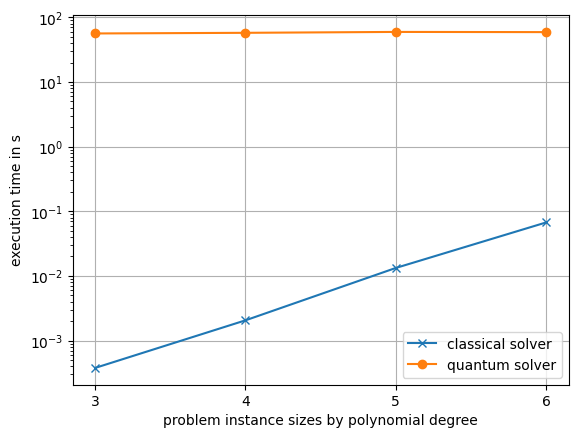

In [ ]:
import matplotlib.pyplot as plt

plt.plot(pol_deg, classic_execution_times, label="classical solver", marker="x")
plt.plot(pol_deg, quantum_execution_times, label="quantum solver", marker="o")

plt.xticks(pol_deg)
plt.xlabel("problem instance sizes by polynomial degree")
plt.ylabel("execution time in s")
plt.yscale('log')
plt.grid()
plt.legend()

plt.show()

---
# RQ 2 QUBOs

In [ ]:
import numpy as np

small_qubos = [h.to_qubo() for h in small_hubos]
small_qubos_props = [[q.num_terms, q.num_binary_variables] for q in small_qubos]

medium_qubos = [h.to_qubo() for h in medium_hubos]
medium_qubos_props = [[q.num_terms, q.num_binary_variables] for q in medium_qubos]

large_qubos = [h.to_qubo() for h in large_hubos]
large_qubos_props = [[q.num_terms, q.num_binary_variables] for q in large_qubos]

extra_large_qubos = [h.to_qubo() for h in extra_large_hubos]
extra_large_qubos_props = [[q.num_terms, q.num_binary_variables] for q in extra_large_qubos]


small_qubos_mean = np.mean(small_qubos_props, axis=0)
print(f"Small QUBO has an average of {small_qubos_mean[0]} terms consisting of {small_qubos_mean[1]} variables")

medium_qubos_mean = np.mean(medium_qubos_props, axis=0)
print(f"Medium QUBO has an average of {medium_qubos_mean[0]} terms consisting of {medium_qubos_mean[1]} variables")

large_qubos_mean = np.mean(large_qubos_props, axis=0)
print(f"Large QUBO has an average of {large_qubos_mean[0]} terms consisting of {large_qubos_mean[1]} variables")

extra_large_qubos_mean = np.mean(extra_large_qubos_props, axis=0)
print(f"XL QUBO has an average of {extra_large_qubos_mean[0]} terms consisting of {extra_large_qubos_mean[1]} variables")

qubos_props= np.array([small_qubos_mean, medium_qubos_mean, large_qubos_mean, extra_large_qubos_mean]).T

Small QUBO has an average of 10.604 terms consisting of 7.263 variables
Medium QUBO has an average of 23.213 terms consisting of 12.104 variables
Large QUBO has an average of 41.539 terms consisting of 18.379 variables
XL QUBO has an average of 65.583 terms consisting of 26.044 variables


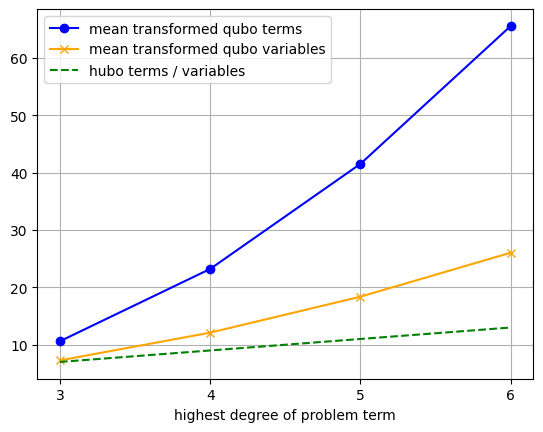

In [ ]:
import matplotlib.pyplot as plt

plt.plot(pol_deg, qubos_props[0], label="mean transformed qubo terms", marker = "o", c="blue")
plt.plot(pol_deg, qubos_props[1], label="mean transformed qubo variables", marker = "x", c="orange")
plt.plot(pol_deg, terms, linestyle='--', label= "hubo terms / variables", c="g")

plt.xticks(pol_deg)
plt.xlabel("highest degree of problem term")
plt.grid()
plt.legend()

plt.show()

In [ ]:
from qubovert.utils import solve_qubo_bruteforce

# reset the iterators
small_hubo = iter(small_hubos)
medium_hubo = iter(medium_hubos)
large_hubo = iter(large_hubos)
extra_large_hubo = iter(extra_large_hubos)

def solve_as_qubo(hubo: PUBO):
  qubo = hubo.to_qubo()
  _, sol = solve_qubo_bruteforce(qubo)


qubo_execution_time_classic_small = timeit.timeit(lambda: solve_as_qubo(next(small_hubo)), number=1000) / 1000
print(f"Average execution time for small HUBO with classical solver: {qubo_execution_time_classic_small:.8f}s")

qubo_execution_time_classic_medium = timeit.timeit(lambda: solve_as_qubo(next(medium_hubo)), number=500) / 500
print(f"Average execution time for medium HUBO with classical solver: {qubo_execution_time_classic_medium:.6f}s")

qubo_execution_time_classic_large = timeit.timeit(lambda: solve_as_qubo(next(large_hubo)), number=10) / 10
print(f"Average execution time for large HUBO with classical solver: {qubo_execution_time_classic_large:.4f}s")

qubo_execution_time_classic_extra_large = timeit.timeit(lambda: solve_as_qubo(next(extra_large_hubo)), number=1) / 1
print(f"Average execution time for extra large HUBO with classical solver: {qubo_execution_time_classic_extra_large:.4f}s")

qubo_classic_execution_times = [qubo_execution_time_classic_small, qubo_execution_time_classic_medium, qubo_execution_time_classic_large, qubo_execution_time_classic_extra_large]

Average execution time for small HUBO with classical solver: 0.00186904s
Average execution time for medium HUBO with classical solver: 0.048699s
Average execution time for large HUBO with classical solver: 4.2839s
Average execution time for extra large HUBO with classical solver: 1098.5347s


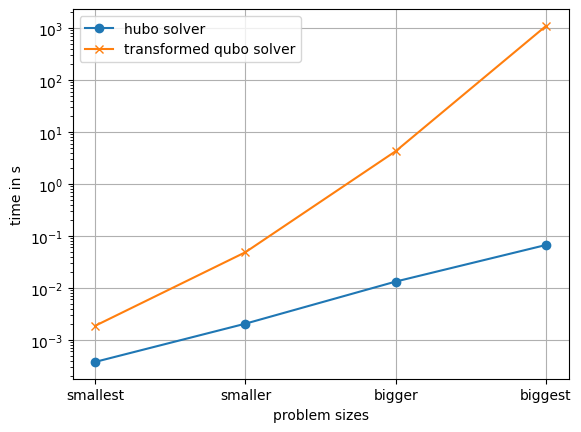

In [ ]:
import matplotlib.pyplot as plt

plt.plot(pol_deg, classic_execution_times, label="hubo solver", marker = "o")
plt.plot(pol_deg, qubo_classic_execution_times, label="transformed qubo solver", marker = "x")

plt.xticks(pol_deg, labels=['smallest','smaller','bigger', 'biggest'])
plt.xlabel("problem sizes")
plt.ylabel("time in s")
plt.yscale('log')
plt.grid()
plt.legend()

plt.show()